# 🪙 Path of Exile 2 Economy Data Explorer

Note: This is generated with ChatGPT, to show an example of use.

This notebook downloads and caches market data from [poe.ninja](https://poe.ninja/poe2/economy/) using the `pyoe2_craftpath` library, parses it into an economy object, and provides tools to explore and visualize the results.

In [1]:
import os
import pandas as pd
import pyoe2_craftpath as pc

## Configuration

In [2]:
MARKET_MAP = {
    "./cache/pn_abyss.json": "https://poe.ninja/poe2/api/economy/exchange/current/overview?league=Standard&type=Abyss",
    "./cache/pn_currency.json": "https://poe.ninja/poe2/api/economy/exchange/current/overview?league=Standard&type=Currency",
    "./cache/pn_essences.json": "https://poe.ninja/poe2/api/economy/exchange/current/overview?league=Standard&type=Essences",
    "./cache/pn_ritual.json": "https://poe.ninja/poe2/api/economy/exchange/current/overview?league=Standard&type=Ritual"
}

CACHE_TTL_IN_SECONDS = 60 * 60  # 1 hour

os.makedirs("./cache", exist_ok=True)

## Fetch or Load Cached Data With Inbuilt Function

In [3]:
raw_fetched_responses = pc.retrieve_contents_from_urls_with_cache_unstable_order(
    cache_url_map=MARKET_MAP,
    max_cache_duration_in_sec=CACHE_TTL_IN_SECONDS
)

print(f"Loaded {len(raw_fetched_responses)} market data files.")

2026-06-12T03:38:22.505670Z  INFO retrieve_contents_from_urls_with_cache_unstable_order: Loading cached contents from './cache/pn_currency.json'
Loaded 4 market data files.
2026-06-12T03:38:22.508908Z  INFO retrieve_contents_from_urls_with_cache_unstable_order: Loading cached contents from './cache/pn_abyss.json'
2026-06-12T03:38:22.511665Z  INFO retrieve_contents_from_urls_with_cache_unstable_order: Loading cached contents from './cache/pn_ritual.json'
2026-06-12T03:38:22.514104Z  INFO retrieve_contents_from_urls_with_cache_unstable_order: Loading cached contents from './cache/pn_essences.json'


## Parse the Economy Data

In [4]:
economy = pc.PoeNinjaMarketPriceProvider.parse_from_json_list(
    raw_fetched_responses)

## Basic Validations

In [5]:
# poe.ninja prunes items that have not traded recently, so only the three
# reference currencies are guaranteed to stay listed - probe those plus the
# overall parse result instead of asserting on tradeable item names
print(f"Parsed {len(economy.cache_market_prices)} market prices")
assert len(economy.cache_market_prices) > 0

test_divine = economy.cache_market_prices.get(pc.ItemName("Divine Orb"))
test_exalted = economy.cache_market_prices.get(pc.ItemName("Exalted Orb"))
test_chaos = economy.cache_market_prices.get(pc.ItemName("Chaos Orb"))

assert test_divine is not None
assert test_exalted is not None
assert test_chaos is not None

print("✅ Economy data loaded and validated successfully!")


Parsed 117 market prices
✅ Economy data loaded and validated successfully!


## Example Conversions

In [6]:
# pick a tradeable item from the parsed data and convert its price into
# the three reference currencies
example_name, example_price = next(iter(economy.cache_market_prices.items()))

print(f"Item: {example_name.raw_value}")
print("Divine Value:", economy.currency_convert(example_price, pc.PriceKind.Divine))
print("Exalted Value:", economy.currency_convert(example_price, pc.PriceKind.Exalted))
print("Chaos Value:", economy.currency_convert(example_price, pc.PriceKind.Chaos))


Item: Fracturing Orb
Divine Value: 16.78
Exalted Value: 5946.832
Chaos Value: 85.2424


## Convert Market Prices to DataFrame

In [7]:
data = [
    {
        "Item": str(item_name.raw_value), # (move out of wrapper to str)
        "Value (Divine)": price.get_divine_value(),
        "Value (Chaos)": economy.currency_convert(price, pc.PriceKind.Chaos),
        "Value (Exalted)": economy.currency_convert(price, pc.PriceKind.Exalted),
    }
    for item_name, price in economy.cache_market_prices.items()
]

df = pd.DataFrame(data).sort_values(by="Value (Divine)", ascending=False)
df.head(20)

,Item,Value (Divine),Value (Chaos),Value (Exalted)
92,Mirror of Kalandra,11349.00,57652.9200,4022085.600
80,Hinekora's Lock,4317.00,21930.3600,1529944.800
18,Raven-Touched Shard,3000.00,15240.0000,1063200.000
8,Vaal Catalysing Infuser,1370.00,6959.6000,485528.000
32,Kurgal's Gaze,499.30,2536.4440,176951.920
24,Omen of Chance,407.00,2067.5600,144240.800
58,Omen of Sinistral Erasure,237.20,1204.9760,84063.680
88,Altered Collarbone,230.50,1170.9400,81689.200
101,Ancient Collarbone,225.40,1145.0320,79881.760
102,Omen of Light,217.80,1106.4240,77188.320


## Plot Top 20 Most Valuable Items (Divine Value)

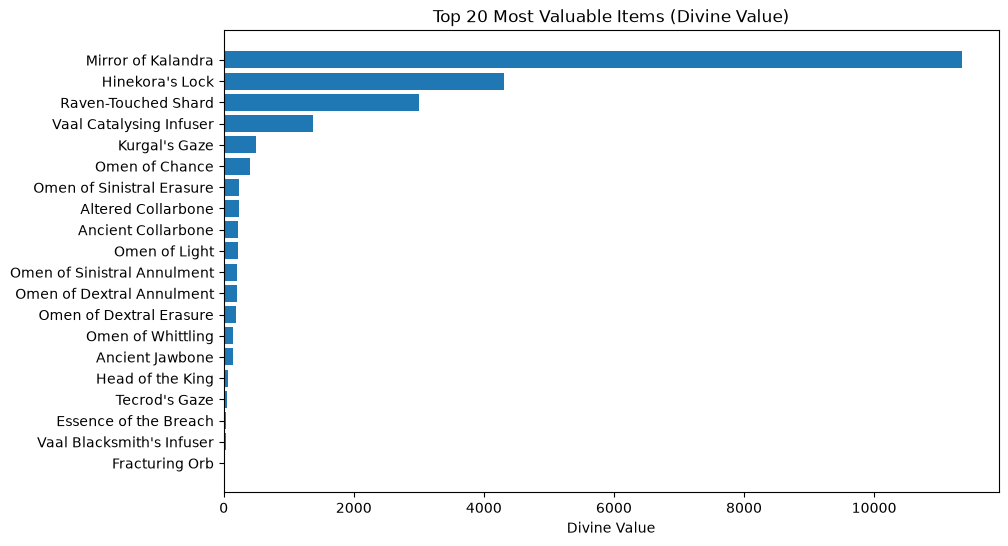

In [8]:
import matplotlib.pyplot as plt

top20 = df.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top20["Item"], top20["Value (Divine)"])
plt.gca().invert_yaxis()
plt.xlabel("Divine Value")
plt.title("Top 20 Most Valuable Items (Divine Value)")
plt.show()

## Search Utility

In [9]:
def search_item(name_fragment: str):
    """Search for items by partial name."""
    return df[df["Item"].str.contains(name_fragment, case=False, na=False)]

# Example:
search_item("Divine")

,Item,Value (Divine),Value (Chaos),Value (Exalted)
20,Divine Orb,1.0,5.08,354.4


## Interactive Exploration
You can re-run the search cell with different phrases like `"Essence"`, `"Omen"`, `"Orb"`, etc.